In [ ]:
import os

import torch
from torch.utils.data import TensorDataset

from models.cnn_numerical import CNNTimeSeriesPredictor
from models.utils_models import load_and_prepare_data
from visualization.utils_visualization import plot_predictions_numerical_model

### Numerical ECG

In [2]:
base_dir = os.getcwd()
ckpt_file = "epoch=epoch=14-val_loss=val_loss=0.014259.ckpt"
model_ecg_numerical = CNNTimeSeriesPredictor.load_from_checkpoint(
    os.path.join(base_dir, "checkpoints/cnn_numerical_ecg", ckpt_file),
    map_location=torch.device("cpu")
)

/opt/anaconda3/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.5.1


In [3]:
model_ecg_numerical.eval()

CNNTimeSeriesPredictor(
  (conv_layers): ModuleList(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (fc1): Linear(in_features=3840, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=60, bias=True)
  (relu): ReLU()
)

In [ ]:
file_path_test = os.path.join(base_dir, "..", "..", "data", "data_storage", "ecg_parquets", "test_ecg.parquet")
X_test, y_test = load_and_prepare_data(file_path_test, prediction_percentage=0.25)
val_dataset_ecg = TensorDataset(torch.stack(X_test), torch.stack(y_test))

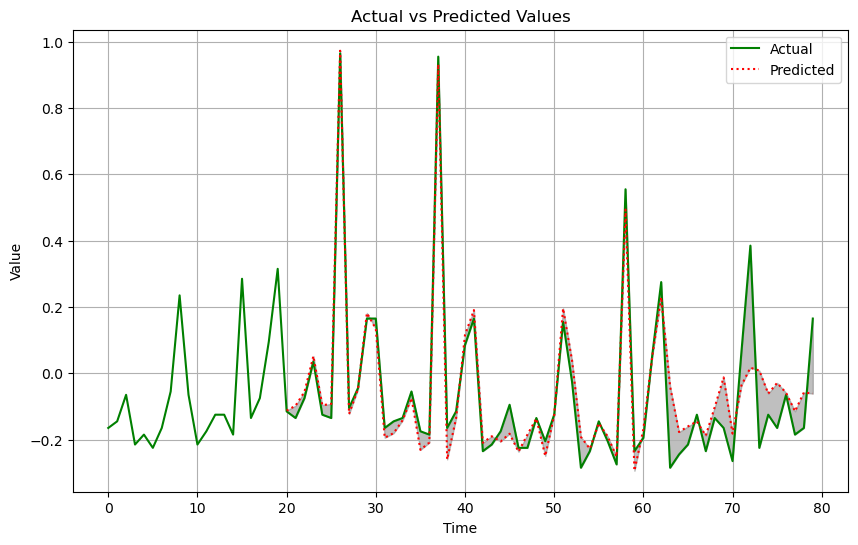

In [64]:
plot_predictions_numerical_model(model_ecg_numerical, val_dataset_ecg, n_plots=1, all_predictions = True)

### Numerical Harmonic

In [6]:
ckpt_file = "epoch=epoch=45-val_loss=val_loss=0.030481.ckpt"
model_harmonic_numerical = CNNTimeSeriesPredictor.load_from_checkpoint(
    os.path.join(base_dir, "checkpoints/cnn_numerical_harmonic", ckpt_file),
    map_location=torch.device("cpu")
)

/opt/anaconda3/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v2.5.1


In [7]:
model_harmonic_numerical.eval()

CNNTimeSeriesPredictor(
  (conv_layers): ModuleList(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (fc1): Linear(in_features=7680, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=60, bias=True)
  (relu): ReLU()
)

In [8]:
file_path_test = os.path.join(base_dir, "..", "..", "data", "data_storage", "harmonic_ou_parquets", "test_harmonic.parquet")
X_test, y_test = load_and_prepare_data(file_path_test, prediction_percentage=0.25)
val_dataset_harmonic = TensorDataset(torch.stack(X_test), torch.stack(y_test))

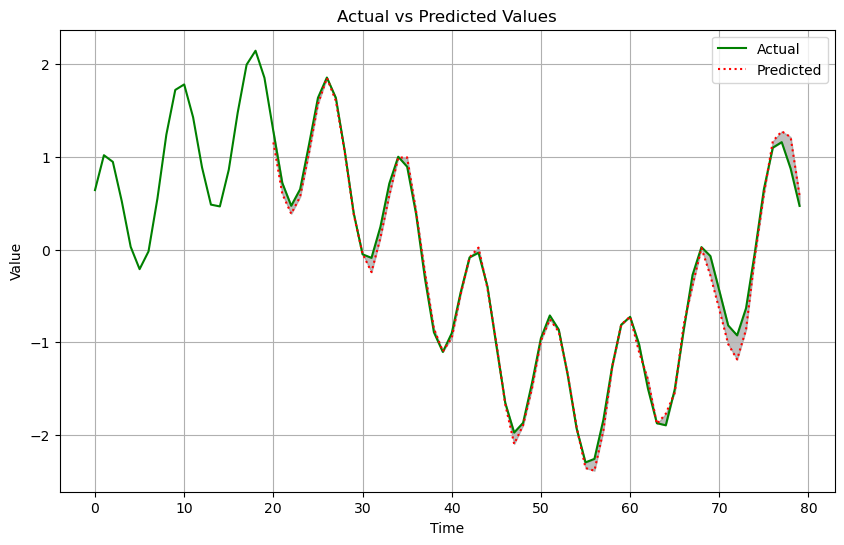

In [78]:
plot_predictions_numerical_model(model_harmonic_numerical, val_dataset_harmonic, n_plots=1, all_predictions = True)

### Numerical OU

In [10]:
ckpt_file = "epoch=epoch=15-val_loss=val_loss=0.176537.ckpt"
model_ou_numerical = CNNTimeSeriesPredictor.load_from_checkpoint(
    os.path.join(base_dir, "checkpoints/cnn_numerical_ou", ckpt_file),
    map_location=torch.device("cpu")
)

In [11]:
model_ou_numerical.eval()

CNNTimeSeriesPredictor(
  (conv_layers): ModuleList(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (2): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (fc1): Linear(in_features=3840, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=60, bias=True)
  (relu): ReLU()
)

In [12]:
file_path_test = os.path.join(base_dir, "..", "..", "data", "data_storage", "harmonic_ou_parquets", "test_ou.parquet")
X_test, y_test = load_and_prepare_data(file_path_test, prediction_percentage=0.25)
val_dataset_ou = TensorDataset(torch.stack(X_test), torch.stack(y_test))

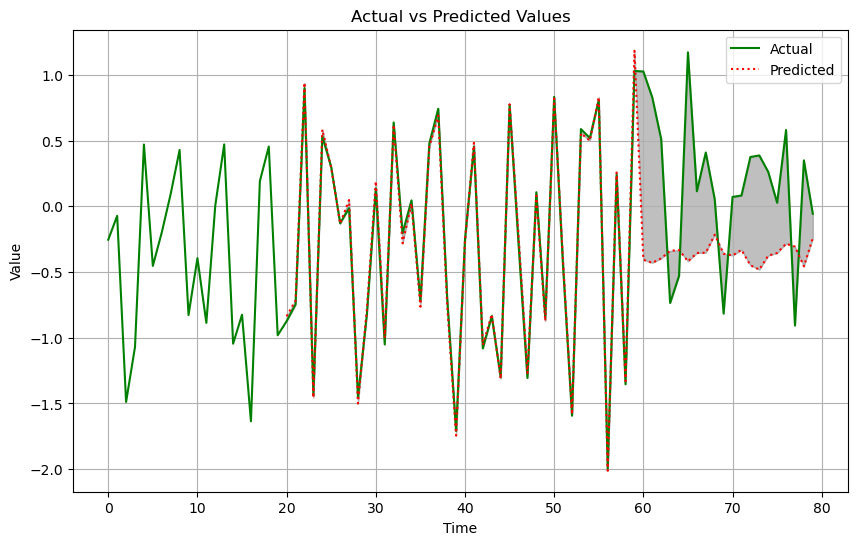

In [86]:
plot_predictions_numerical_model(model_ou_numerical, val_dataset_ou, n_plots=1, all_predictions = True)

### Numerical S&P

In [ ]:
ckpt_file_sp = "epoch=epoch=5-val_loss=val_loss=0.112760.ckpt"  
model_sp_numerical = CNNTimeSeriesPredictor.load_from_checkpoint(
    os.path.join(base_dir, "checkpoints/cnn_numerical_sp500", ckpt_file_sp),
)

In [15]:
model_sp_numerical.eval()

CNNTimeSeriesPredictor(
  (conv_layers): ModuleList(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (2): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(3,))
    (3): Conv1d(256, 512, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (fc1): Linear(in_features=30720, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=60, bias=True)
  (relu): ReLU()
)

In [16]:
file_path_test_sp = os.path.join(base_dir, "..", "..", "data", "data_storage", "sp500_parquets", "test_sp500.parquet") # TODO: Verify this path to your S&P test data
X_test_sp, y_test_sp = load_and_prepare_data(file_path_test_sp, prediction_percentage=0.25)
val_dataset_sp = TensorDataset(torch.stack(X_test_sp), torch.stack(y_test_sp))

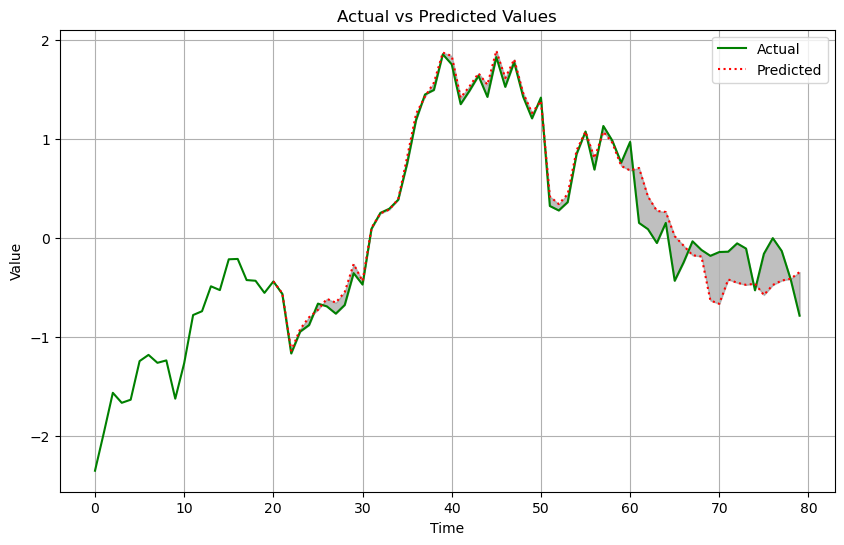

In [145]:
plot_predictions_numerical_model(model_sp_numerical, val_dataset_sp, n_plots=1, all_predictions = True)